:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`variable_selection_zero_basis.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Ignore convergence (irrelevant for this note)
# For real neural data analyis, increase solver maxiter if warning is raised.
warnings.filterwarnings(
    "ignore",
    message=(
        "The fit did not converge"
    ),
    category=RuntimeWarning,
)

jax.config.update("jax_enable_x64", True)

(variable_selection)=
# Model Selection: Cross-validate over Inputs

When modeling neural activity with multiple inputs, you may want to determine which inputs are necessary. The `Zero` basis acts as a placeholder that contributes no features, allowing you to systematically test different input combinations.

## Load data

We'll use place cell data to test whether position, theta phase, or both are needed to predict neural responses. See the [place cells tutorial](place-cells-data) for details on this dataset.

In [2]:
import nemos as nmo
import pynapple as nap
from sklearn.model_selection import cross_val_score

# Fetch data
path = nmo.fetch.fetch_data("Achilles_10252013.nwb")
data = nap.load_file(path)

# Get spikes, position, and theta phase
spikes = data["units"].getby_category("cell_type")["pE"]
position = data["position"].restrict(data["trials"])
theta = data["theta_phase"]

# Select one neuron and bin spikes
neuron = spikes[82]
bin_size = 0.1
counts = neuron.count(bin_size, ep=position.time_support)

# Align position and theta to spike counts
position = position.interpolate(counts, ep=counts.time_support)
theta = theta.interpolate(counts, ep=counts.time_support)

  0%|                                               | 0.00/765M [00:00<?, ?B/s]

## Cross-validate over inputs

We'll use [scikit-learn's cross-validation](sklearn-how-to) to compare models with different input combinations.

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# Define complete basis configurations
position_basis = nmo.basis.BSplineEval(
    n_basis_funcs=10,
    bounds=(position.min(), position.max()),
)
theta_basis = nmo.basis.CyclicBSplineEval(
    n_basis_funcs=8,
    bounds=(-np.pi, np.pi),
)

# Use Zero as placeholder for excluded inputs
basis_both = position_basis + theta_basis
basis_position = position_basis + nmo.basis.Zero()
basis_theta = nmo.basis.Zero() + theta_basis

basis_both.label = "both"
basis_position.label = "position"
basis_theta.label = "theta"


# Set up pipeline
pipeline = Pipeline([
    ("basis", basis_both.to_transformer()),
    ("glm", nmo.glm.GLM(solver_name="LBFGS"))
])

# Test different input combinations
param_grid = {
    "basis__basis": [
        basis_both,     # position + theta
        basis_position, # position only
        basis_theta     # theta only
    ],
}

# Run grid search
gridsearch = GridSearchCV(pipeline, param_grid=param_grid, cv=5)
X = np.column_stack([position, theta])
gridsearch.fit(X, counts.d)
gridsearch

/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...me='LBFGS'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'basis__basis': ['both': Addit..._value=nan), ), 'position': A...sis2=Zero(), ), ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

The most predictive encoding model for this neuron includes position only. Below the comparison of the tuning curves.

/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


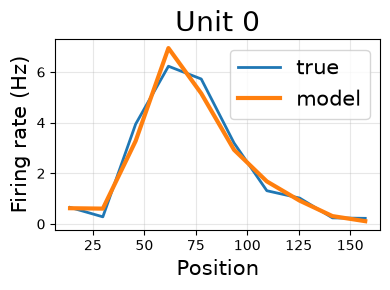

In [4]:
import matplotlib.pyplot as plt

# Compute and plot tuning curves
tc_position = nap.compute_tuning_curves(
    neuron, position, bins=10, feature_names=["position"]
)
tc_position_model = nap.compute_tuning_curves(
    gridsearch.predict(X) * X.rate, position, bins=10, feature_names=["position"]
)

# Plot tuning curves
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
tc_position.squeeze().plot(ax=ax, linewidth=2, markersize=6, label="true")
tc_position_model.squeeze().plot(ax=ax, linewidth=3, markersize=6, label="model")
ax.set_ylabel('Firing rate (Hz)', fontsize=15)
ax.set_xlabel('Position', fontsize=15)
ax.set_title(f'Unit {tc_position.coords["unit"].values[0]}', fontsize=20)
ax.grid(True, alpha=0.3)
plt.legend(fontsize=15)
plt.tight_layout()

In [5]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "variable_selection_zero_basis.svg")